# Maximal Correlation: Non-Linear Benchmarks
This notebook empirically validates the `maxcorr` library against 13 distinct synthetic topologies.
It compares the performance of the Single Kernel (SK) and Double Kernel (DK) algorithms, demonstrating their ability to detect non-linear dependencies where standard Pearson correlation fails (e.g., scoring ~0).

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

from benchmark_nonlinear import NonLinearIndicatorTester, NonLinearVisualizer
from benchmark_nonlinear import NonLinearDatasetGenerator

## 1. The Topologies
We evaluate the algorithms against a variety of manifolds, continuous curves, and discontinuous step functions. Each dataset is injected with 10% Gaussian
noise to simulate real-world variance.

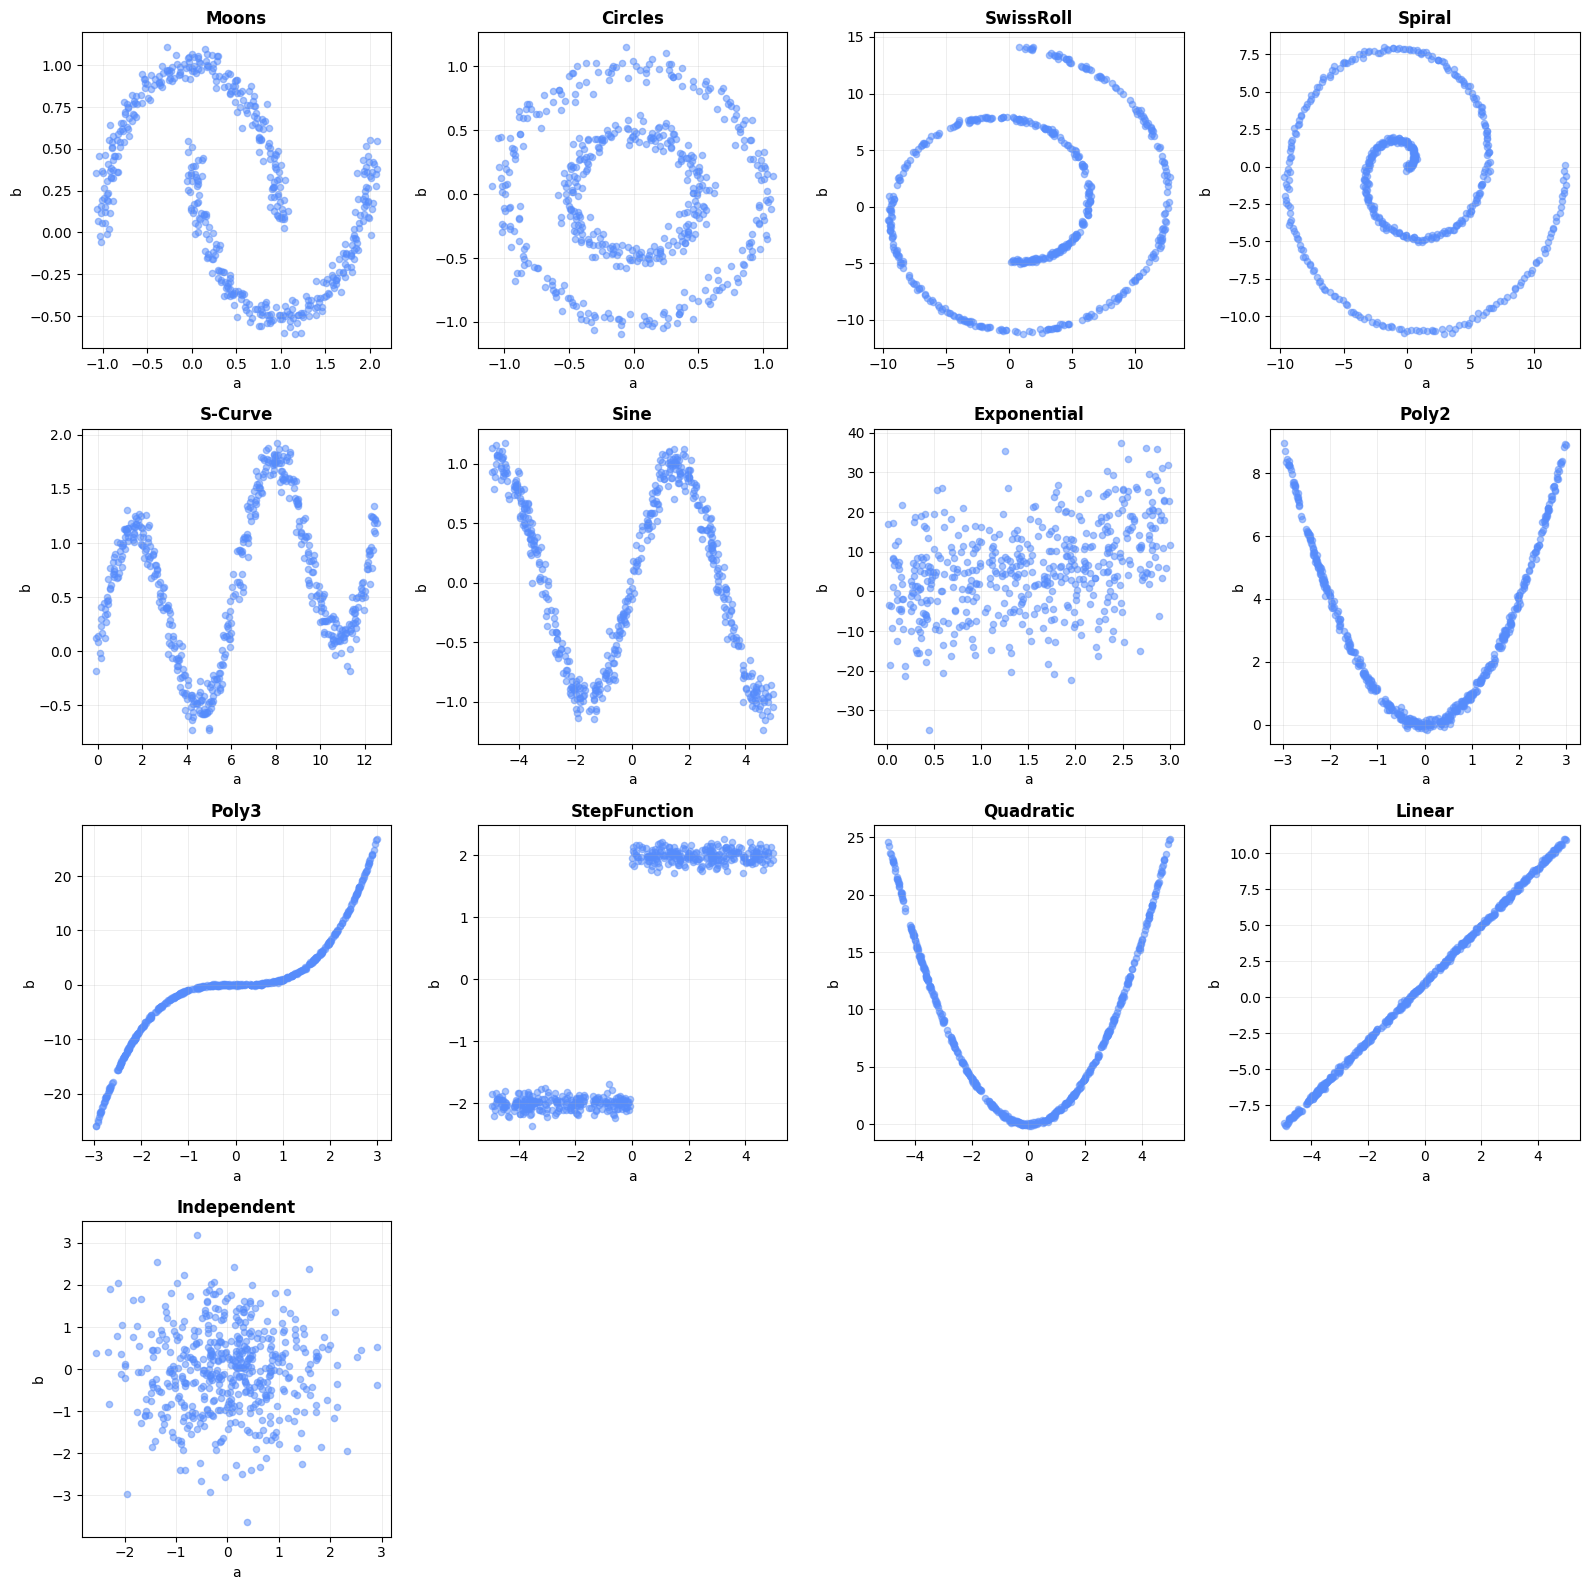

In [2]:
# Visualize the 13 synthetic datasets
NonLinearVisualizer.plot_datasets(n_samples=500, random_state=42)

## 2. Head-to-Head Evaluation (SK vs DK)
We utilize a 5-fold cross-validation strategy to prevent overfitting. The `NonLinearInterpreter` automatically flags suboptimal performance, structural limits, or false-positive hallucinations on independent noise.

In [3]:
# Initialize the testing suite
tester = NonLinearIndicatorTester(verbose=False)

# Run the benchmark across all datasets for both algorithms
df_results = tester.test_all_datasets(
    algorithms=["sk", "dk"],
    n_splits=5,
    random_state=42,
)

# Display the final cross-validated metrics
tester.print_summary()


Testing 13 Non-Linear Datasets

Testing 13 Datasets across 2 Algorithms

SUMMARY OF RESULTS

     Dataset Algorithm  Test Score  Test Std  Train Score  Train Std  Overfitting Gap       Status                    Best Params
       Moons        sk    0.640675  0.044236     0.646649   0.011752         0.005974 ⚠️  Moderate                  {'kernel': 5}
       Moons        dk    0.633456  0.045522     0.651737   0.011819         0.018281 ⚠️  Moderate {'kernel_a': 3, 'kernel_b': 3}
     Circles        sk   -0.095802  0.067419     0.042618   0.011415         0.138421       ❌ Poor                  {'kernel': 3}
     Circles        dk    0.276305  0.073525     0.298238   0.017411         0.021932       ❌ Poor {'kernel_a': 3, 'kernel_b': 3}
   SwissRoll        sk    0.144480  0.078875     0.187647   0.016688         0.043166       ❌ Poor                  {'kernel': 5}
   SwissRoll        dk    0.717353  0.036277     0.734491   0.007142         0.017137       ✅ Good {'kernel_a': 5, 'kernel_b':

In [4]:
tester.get_results_dataframe()

,Dataset,Algorithm,Test Score,Test Std,Train Score,Train Std,Overfitting Gap,Status,Best Params
0,Moons,sk,0.640675,0.044236,0.646649,0.011752,0.005974,⚠️ Moderate,{'kernel': 5}
1,Moons,dk,0.633456,0.045522,0.651737,0.011819,0.018281,⚠️ Moderate,"{'kernel_a': 3, 'kernel_b': 3}"
2,Circles,sk,-0.095802,0.067419,0.042618,0.011415,0.138421,❌ Poor,{'kernel': 3}
3,Circles,dk,0.276305,0.073525,0.298238,0.017411,0.021932,❌ Poor,"{'kernel_a': 3, 'kernel_b': 3}"
4,SwissRoll,sk,0.144480,0.078875,0.187647,0.016688,0.043166,❌ Poor,{'kernel': 5}
5,SwissRoll,dk,0.717353,0.036277,0.734491,0.007142,0.017137,✅ Good,"{'kernel_a': 5, 'kernel_b': 5}"
6,Spiral,sk,0.184472,0.038678,0.218105,0.010282,0.033632,❌ Poor,{'kernel': 5}
7,Spiral,dk,0.596568,0.081479,0.616430,0.022691,0.019861,⚠️ Moderate,"{'kernel_a': 5, 'kernel_b': 4}"
8,S-Curve,sk,0.924424,0.006940,0.926217,0.001513,0.001793,✅ Excellent,{'kernel': 5}
9,S-Curve,dk,0.937853,0.008263,0.940166,0.001748,0.002313,✅ Excellent,"{'kernel_a': 5, 'kernel_b': 5}"


## 3. Visual Proofs of Transformation

### The Perfect Baseline: Sine Wave
To prove the Double Kernel actively linearizes non-linear manifolds, we first look at a continuous periodic function. Because polynomial kernels approximate Taylor expansions, the algorithm achieves a near-perfect transformation without edge artifacts.

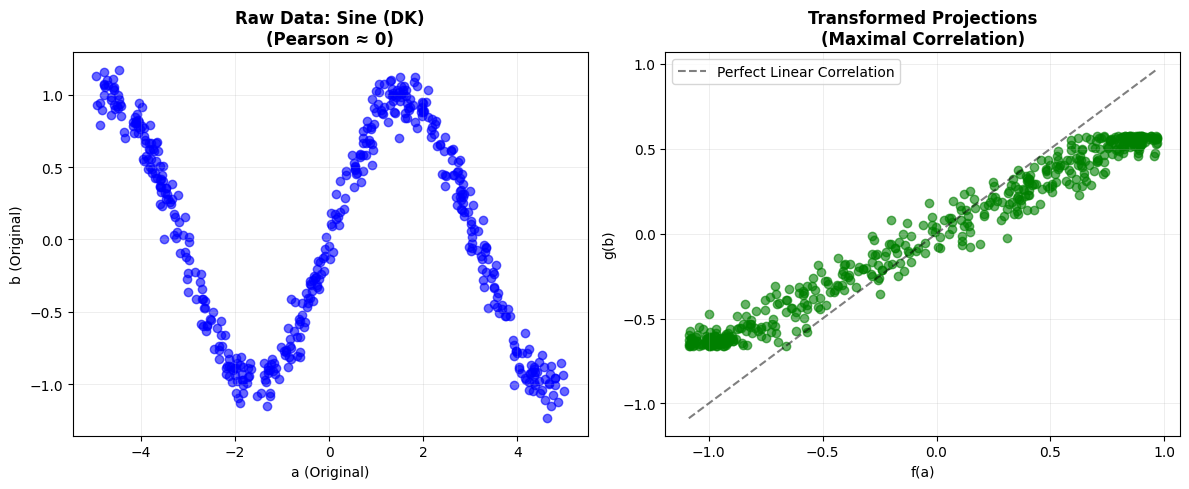

In [5]:
# Generate the Sine dataset
a_sine, b_sine, name_sine = NonLinearDatasetGenerator.sine_wave(
    n_samples=500,
    random_state=42,
)

# Test and plot the baseline transformation
result_sine = tester.test_dataset(
    a_sine,
    b_sine,
    dataset_name=name_sine,
    algorithm="dk",
    plot_transformations=True,
)

In [6]:
result_sine

TestResult(Sine, dk, test=0.9874±0.0013, train=0.9881±0.0003, gap=0.0007, ✅ Excellent)

### The Capacity Limit: Interlocking Moons
To demonstrate the impact of kernel capacity on interlocking manifolds, we expand the hyperparameter grid to allow the algorithm to utilize polynomials up to degree 11. While it successfully linearizes the shape, we begin to observe Runge's Phenomenon ("clamping" artifacts) at the extreme boundaries.

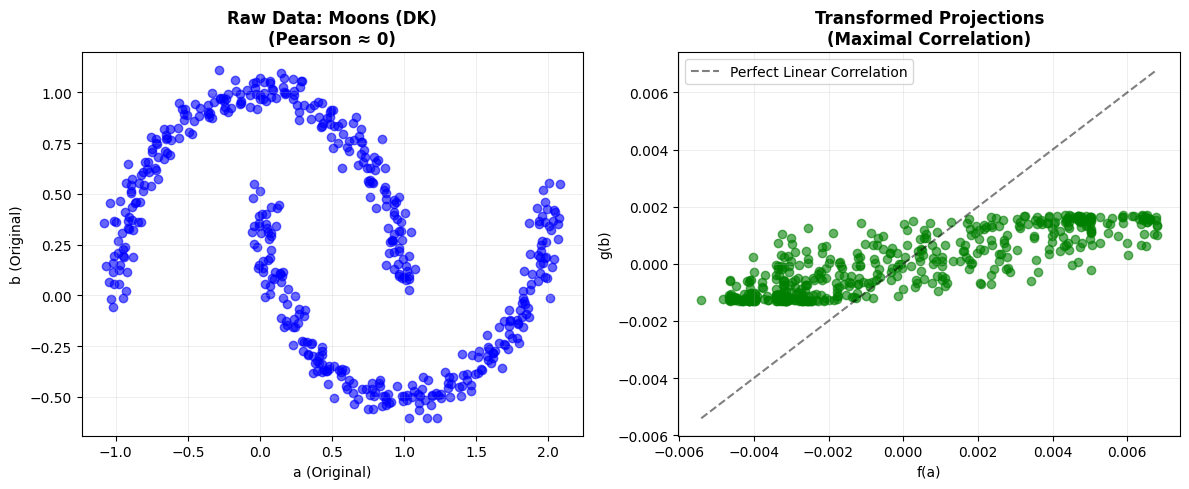

In [7]:
# Generate the Moons dataset
a_moons, b_moons, name_moons = NonLinearDatasetGenerator.moons(
    n_samples=500,
    random_state=42,
)

# Test with an expanded polynomial grid
expanded_grid = {"kernel_a": [5, 7, 9, 11], "kernel_b": [5, 7, 9, 11]}

result_moons = tester.test_dataset(
    a_moons,
    b_moons,
    dataset_name=name_moons,
    param_grid=expanded_grid,
    algorithm="dk",
    plot_transformations=True,
)

In [8]:
result_moons

TestResult(Moons, dk, test=0.8237±0.0327, train=0.8476±0.0075, gap=0.0239, ✅ Good)

### The Structural Limit: Swiss Roll
While the algorithm successfully mapped the 2D Moons, it mathematically struggles with 3D manifolds like the Swiss Roll. Because Polynomial kernels rely on Euclidean distance rather than Geodesic distance, they cannot "unroll" the spiral. Instead, they take a mathematical "slice" through the layers. This results in a hard scoring ceiling (capped around ~0.84) and visually disjointed projections.

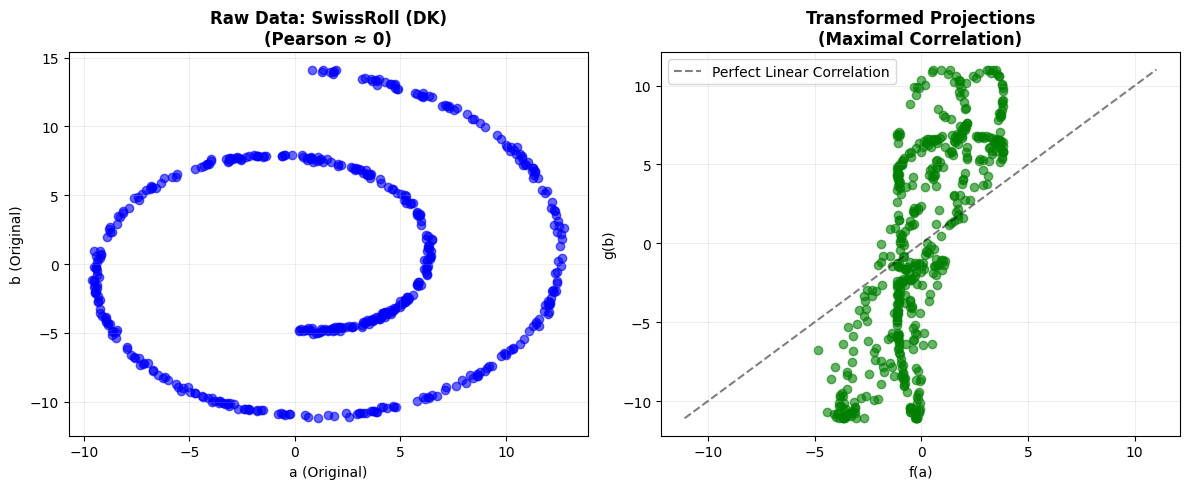

In [9]:
# Generate the Swiss Roll dataset
a_swiss, b_swiss, name_swiss = NonLinearDatasetGenerator.swiss_roll(
    n_samples=500,
    random_state=42,
)

# Test and plot the transformation (Notice it caps around 0.72 and fails to perfectly linearize)
result_swiss = tester.test_dataset(
    a_swiss,
    b_swiss,
    dataset_name=name_swiss,
    algorithm="dk",
    plot_transformations=True,
)

In [10]:
result_swiss

TestResult(SwissRoll, dk, test=0.7174±0.0363, train=0.7345±0.0071, gap=0.0171, ✅ Good)

### The False-Positive Safeguard: Independent Noise
Finally, we must prove that the algorithm does not hallucinate dependencies when given pure noise. We feed the Double Kernel two completely uncorrelated Gaussian vectors. Thanks to the rigorous cross-validation penalty, the algorithm rejects spurious patterns, resulting in a near-zero correlation score and a visually random transformation cloud.

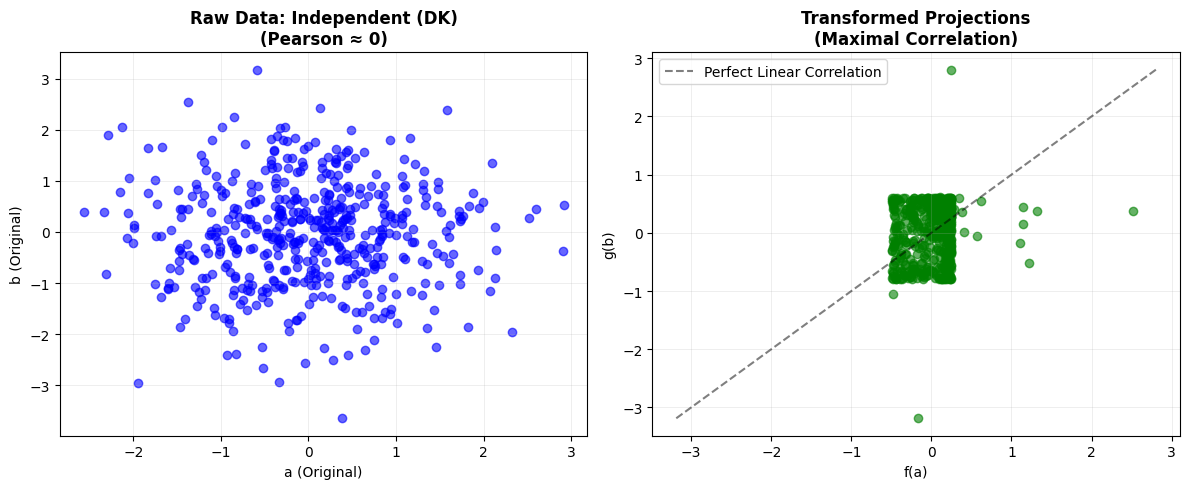

In [11]:
# Generate the Independent Noise dataset
a_indep, b_indep, name_indep = NonLinearDatasetGenerator.independent(
    n_samples=500,
    random_state=42,
)

# Test and plot the transformation (Notice the score safely stays near 0.07)
result_indep = tester.test_dataset(
    a_indep,
    b_indep,
    dataset_name=name_indep,
    algorithm="dk",
    plot_transformations=True,
)

In [12]:
result_indep

TestResult(Independent, dk, test=0.0788±0.0432, train=0.1422±0.0096, gap=0.0634, ❌ Poor)